In [1]:
import pandas as pd
from data_preparation import Data_Preparation as dp
prep = dp()
df = prep.prepare_data_general()
X = df.drop(columns=['PumpTimeInSeconds','WaterLevel'])
y = df['PumpTimeInSeconds']
X

,Temperature,AirHumidity,SoilHumidity,LightIntensity,seconds_since_watering,OptimalTemperature,OptimalAirHumidity,OptimalSoilHumidity,OptimalLightIntensity
0,23.64,45.55,62.13,418.42,0.0,23.1,40.8,58.3,411.6
1,16.36,56.99,68.14,672.59,0.0,18.0,51.2,74.1,594.6
2,27.94,62.90,84.01,391.15,0.0,25.4,67.8,74.0,352.8
3,19.03,38.40,65.96,650.37,0.0,18.1,43.9,60.6,691.0
4,23.19,49.82,59.39,384.56,0.0,21.6,48.9,65.8,466.8
...,...,...,...,...,...,...,...,...,...
149995,25.07,78.11,66.42,264.78,273600.0,22.5,68.6,73.3,336.3
149996,21.58,48.35,71.55,617.51,32400.0,18.0,51.2,74.1,594.6
149997,23.15,34.23,58.41,432.24,61200.0,23.1,40.8,58.3,411.6
149998,19.88,35.86,50.48,602.92,64800.0,23.2,41.8,54.8,546.8


In [2]:
from sklearn.model_selection import  train_test_split
# Assuming X is your feature matrix and y is your target variable
# First split into training and temp (validation + test)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train,X_val,y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.20, random_state=42)
X_train

,Temperature,AirHumidity,SoilHumidity,LightIntensity,seconds_since_watering,OptimalTemperature,OptimalAirHumidity,OptimalSoilHumidity,OptimalLightIntensity
145775,18.72,46.98,65.40,417.66,262800.0,21.6,48.9,65.8,466.8
61312,17.46,46.85,77.54,642.89,39600.0,18.1,43.9,60.6,691.0
128370,21.16,49.07,56.51,646.34,14400.0,18.9,46.0,61.7,752.1
48242,22.13,38.63,62.42,533.86,82800.0,23.2,41.8,54.8,546.8
54025,27.86,50.06,64.44,397.75,612000.0,23.8,46.1,72.3,434.5
...,...,...,...,...,...,...,...,...,...
49713,21.54,46.52,72.23,792.34,90000.0,18.9,46.0,61.7,752.1
87939,17.27,45.77,76.17,708.08,241200.0,18.0,51.2,74.1,594.6
138288,18.27,50.25,54.25,321.65,75600.0,22.4,51.6,57.2,314.0
78493,18.69,63.10,61.04,668.43,291600.0,19.8,60.6,62.9,701.6


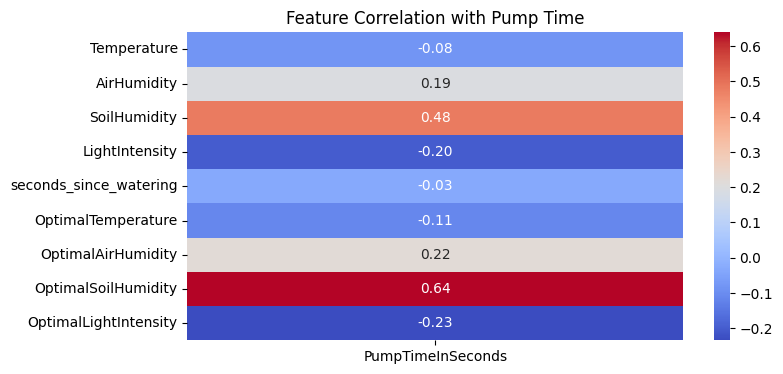

In [3]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# correlation of each feature with target
corr_series = X_train.corrwith(y_train)

plt.figure(figsize=(8, 4))
sns.heatmap(corr_series.to_frame(name='PumpTimeInSeconds'),
            annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation with Pump Time')
plt.show()